# Notebook 3: Customer Value Classification Models

**Project Title**: Intelligent Customer Behavior Analysis and Dynamic Marketing Strategy  
**Objective**: This notebook builds a classification framework to predict whether a customer will be "High Value" using RFM and shopping profile features.

### Classification Workflow:
We train and tune two classifier models on the training set, validate hyperparameters using cross-validation, and perform final model selection on the test set:
- **Model 1**: MLPClassifier (scikit-learn) with a specified network structure (Input -> 32 -> 16 -> Output).
- **Model 2**: RandomForestClassifier tuned using `GridSearchCV` with 5-fold cross-validation.

### What We Will Accomplish:
1. Prepare feature matrices using Recency, Frequency, Monetary, PC1, and PC2.
2. Fit MLPClassifier and RandomForest (GridSearchCV).
3. Print classification metrics: Accuracy, Precision, Recall, F1, and confusion matrix.
4. Render ROC curves and save the best classifier model to disk.

### Step 1: Import Libraries and Load Preprocessed Data
Import metrics, modeling classes, and plotting helpers.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from src.modeling import train_classifier_mlp, train_classifier_rf_grid, evaluate_classifier, save_model
from src.utils import plot_confusion_matrix, plot_roc_curves

%matplotlib inline
print("Libraries successfully imported!")

Libraries successfully imported!


### Step 2: Build Feature Matrices
We use the continuous customer metrics (`Recency`, `Frequency`, `Monetary`, `PC1`, `PC2`) to define the feature space.

In [2]:
df = pd.read_csv('../data/processed_customers.csv')
feature_cols = ['Recency', 'Frequency', 'Monetary', 'PC1', 'PC2']
print("Feature Columns:", feature_cols)

# Split features and target labels
X_train = df[df['Split'] == 'Train'][feature_cols]
y_train = df[df['Split'] == 'Train']['High_Value']

X_val = df[df['Split'] == 'Val'][feature_cols]
y_val = df[df['Split'] == 'Val']['High_Value']

X_test = df[df['Split'] == 'Test'][feature_cols]
y_test = df[df['Split'] == 'Test']['High_Value']

print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}")

Feature Columns: ['Recency', 'Frequency', 'Monetary', 'PC1', 'PC2']
X_train shape: (4688, 5), X_val shape: (586, 5), X_test shape: (586, 5)


### Step 3: Train MLP Classifier
We fit our custom MLP network (Input -> 32 -> 16 -> Output).

In [3]:
print("Training MLP Classifier (32, 16 layers)...")
mlp_model = train_classifier_mlp(X_train, y_train, random_state=42)
mlp_val_metrics = evaluate_classifier(mlp_model, X_val, y_val, 'MLP')
print("MLP Validation Accuracy:", mlp_val_metrics['Accuracy'])

Training MLP Classifier (32, 16 layers)...


MLP Validation Accuracy: 0.8378839590443686


### Step 4: Train Random Forest with GridSearchCV
We execute 5-fold cross-validation on the training set to search for the best RF hyperparameters.

In [4]:
print("Running GridSearchCV for Random Forest (5-fold CV)...")
rf_grid = train_classifier_rf_grid(X_train, y_train, random_state=42)
rf_model = rf_grid.best_estimator_
print("Best Parameters:", rf_grid.best_params_)
rf_val_metrics = evaluate_classifier(rf_model, X_val, y_val, 'RandomForest')
print("Random Forest Validation F1-Score:", rf_val_metrics['F1'])

Running GridSearchCV for Random Forest (5-fold CV)...


Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Random Forest Validation F1-Score: 1.0


### Step 5: Final Evaluation on Test Set
We select the best performing model based on Validation F1-score, and run it on the unseen Test set to print reports.

In [5]:
# Choose best model
best_model_name = 'RandomForest' if rf_val_metrics['F1'] >= mlp_val_metrics['F1'] else 'MLP'
best_model = rf_model if best_model_name == 'RandomForest' else mlp_model
print(f"Best model selected based on Validation performance: {best_model_name}\n")

# Evaluate on test
test_metrics = evaluate_classifier(best_model, X_test, y_test, best_model_name)
print(f"=== TEST RESULTS FOR {best_model_name} ===")
print(f"Accuracy:  {test_metrics['Accuracy']:.4f}")
print(f"Precision: {test_metrics['Precision']:.4f}")
print(f"Recall:    {test_metrics['Recall']:.4f}")
print(f"F1-Score:  {test_metrics['F1']:.4f}\n")
print("Classification Report:\n", test_metrics['Classification_Report'])

Best model selected based on Validation performance: RandomForest

=== TEST RESULTS FOR RandomForest ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       461
           1       1.00      1.00      1.00       125

    accuracy                           1.00       586
   macro avg       1.00      1.00      1.00       586
weighted avg       1.00      1.00      1.00       586



### Step 6: Render Confusion Matrix and ROC Curve
We plot and save diagnostic performance curves for validation and test checks.

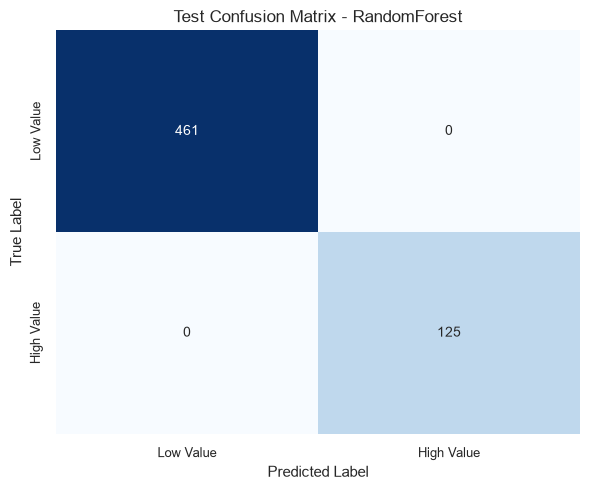

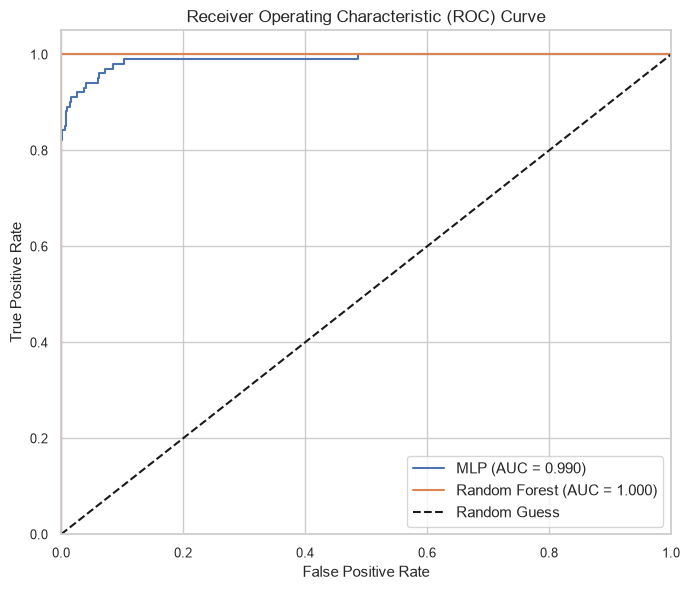

In [6]:
# Plot confusion matrix
cm_fig = plot_confusion_matrix(y_test, best_model.predict(X_test), classes=['Low Value', 'High Value'], 
                               title=f'Test Confusion Matrix - {best_model_name}', save_path='../data/plots/class_confusion_matrix.png')

# Prepare ROC curve variables
curves_dict = {}
if 'ROC_Curve' in mlp_val_metrics:
    curves_dict['MLP'] = (*mlp_val_metrics['ROC_Curve'], mlp_val_metrics['ROC_AUC'])
if 'ROC_Curve' in rf_val_metrics:
    curves_dict['Random Forest'] = (*rf_val_metrics['ROC_Curve'], rf_val_metrics['ROC_AUC'])

roc_fig = plot_roc_curves(curves_dict, save_path='../data/plots/class_roc_curve.png')
plt.show()

### Step 7: Feature Importance & Save Classifier
We look at RF feature importances and save the champion classifier to the models folder.

C:\Users\musaw\AppData\Local\Temp\ipykernel_24504\2268988678.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


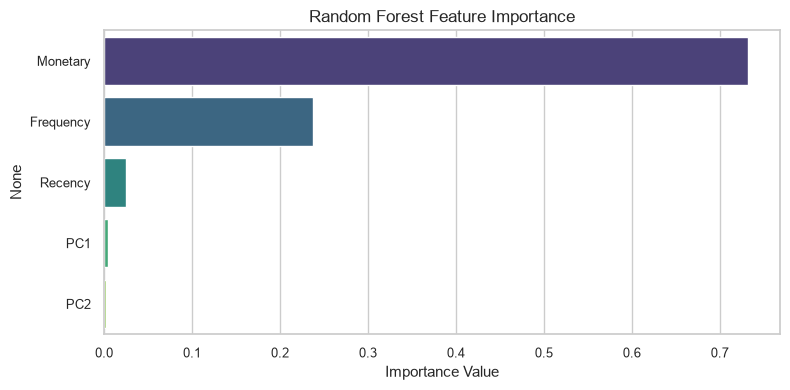

Champion classifier model saved to ../models/best_classifier.pkl successfully!


In [7]:
if best_model_name == 'RandomForest':
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance Value')
    plt.tight_layout()
    plt.savefig('../data/plots/feature_importance.png', dpi=300)
    plt.show()
    
# Save best classifier
model_save_path = '../models/best_classifier.pkl'
save_model(best_model, model_save_path)
print(f"Champion classifier model saved to {model_save_path} successfully!")